# Measurement x=15, y=0, z=0

### TODO


### Imports

In [14]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from python_utils.utils import load_object
from python_utils.time_series_extraction import extract_timeseries_data_by_coordinates_and_column

### General Args

In [15]:
slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
x_coord = 0.01842125  # Closest to 0.
y_coord = 0.01842125
label = 'vx'  # y, z, vx, vy, vz, jx, jy, jz, P, F

### Load Data

In [16]:
pkl_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")

In [17]:
loaded_data = load_object(pkl_path)
timeseries = loaded_data['timeseries']
labels = loaded_data['labels']

print("N =", len(timeseries))
first_snapshot = timeseries[0]
n_x_y, n_v = first_snapshot.shape
n_y = n_z = np.sqrt(n_x_y)
print(f"n_y = {n_y}, n_z = {n_z}, n_v = {n_v}")
print("Labels:")
print(labels)
print("Example Data:")
print(first_snapshot[0:5, 0:3])

Object successfully loaded from c:\Users\hydro\Documents\phd\nuclear_fusion_cooling\data\4pi_re1000_ha300.360_ch28.p1\SliceYZ_x0015\pkl\sliceYZ_x0015_fld.pkl
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 10
Labels:
['y', 'z', 'vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Example Data:
[[-1.        -1.         0.       ]
 [-0.9872207 -1.         0.       ]
 [-0.9667644 -1.         0.       ]
 [-0.9389384 -1.         0.       ]
 [-0.9042407 -1.         0.       ]]


### Print x-Velocity

 x = streamwise

In [18]:
column_index = labels.index(label)
ts = extract_timeseries_data_by_coordinates_and_column(
    arrays=timeseries,
    column_index=column_index,
    y_coord=x_coord,
    z_coord=y_coord,
    )

### Plot Timeseries

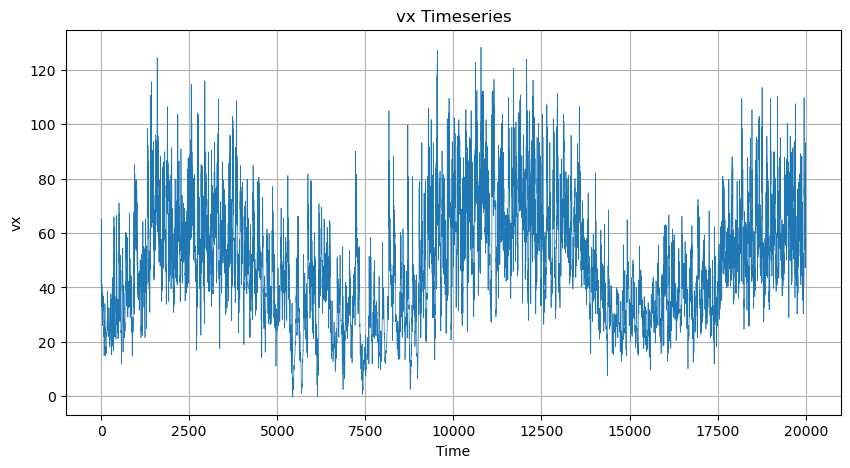

In [22]:
def plot_timeseries(data, title=f"{label} Timeseries", xlabel='Time', ylabel=label, linewidth=1):
    # Create an array for the x-axis (time)
    time = np.arange(len(data))
    
    # Plotting the data with a specified line width
    plt.figure(figsize=(10, 5))
    plt.plot(time, data, linewidth=linewidth)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.show()

plot_timeseries(ts, linewidth=0.5)